## 🎯 Study Session 7 — Regularization, Overfitting, and Model Stability

In [1]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ---------------------------
# 1. Generate synthetic data
# ---------------------------

n = 400

# Bill amount
bill_total_usd = np.round(np.random.uniform(10, 100, n), 2)

# Party size
party_size = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.20, 0.35, 0.25, 0.12, 0.05, 0.03])

# Gender categorical
gender = np.random.choice(["Male", "Female"], size=n)

# Smoker categorical
is_smoker = np.random.choice(["Yes", "No"], size=n, p=[0.30, 0.70])

# ---------------------------
# 2. Create TRUE tip model
# ---------------------------
# True coefficients (this is the "ground truth")
beta_intercept = 0.5
beta_bill      = 0.10
beta_party     = 0.25
beta_gender    = -0.30     # males slightly tip less
beta_smoker    = -0.60     # smokers tip less

# Encode for generating synthetic tip values
gender_code = (gender == "Male").astype(int)
smoker_code = (is_smoker == "Yes").astype(int)

# Predicted tip *before* noise
true_tip = (
    beta_intercept
    + beta_bill * bill_total_usd
    + beta_party * party_size
    + beta_gender * gender_code
    + beta_smoker * smoker_code
)

# Add realistic noise
noise = np.random.normal(0, 2.5, n)

tip_usd = np.maximum(0.5, true_tip + noise)   # Ensure tips can’t go below $0.50

# Tip percentage
tip_pct = tip_usd / bill_total_usd

# ---------------------------
# 3. Build DataFrame
# ---------------------------

df_syn = pd.DataFrame({
    "bill_total_usd": bill_total_usd,
    "party_size": party_size,
    "gender": gender,
    "is_smoker": is_smoker,
    "tip_usd": np.round(tip_usd, 2),
})

df_syn["tip_pct"] = (df_syn["tip_usd"] / df_syn["bill_total_usd"]).round(3)

# ---------------------------
# 4. Save to disk
# ---------------------------

output_path = "data/processed/tips_synthetic.csv"
df_syn.to_csv(output_path, index=False)

print(f"✅ Synthetic dataset saved to: {output_path}")
df_syn.head()


✅ Synthetic dataset saved to: data/processed/tips_synthetic.csv


,bill_total_usd,party_size,gender,is_smoker,tip_usd,tip_pct
0,43.71,1,Female,Yes,3.65,0.084
1,95.56,4,Male,No,9.88,0.103
2,75.88,2,Female,No,7.78,0.103
3,63.88,4,Male,No,12.78,0.200
4,24.04,2,Female,No,4.36,0.181


In [3]:
import pandas as pd

df = pd.read_csv("data/processed/tips_synthetic.csv")

# Encode gender/smoker safely
df_work = df.copy()

if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X = df_work[features]
y = df_work["tip_usd"]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
enet  = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_train, y_train)

ridge_coef = pd.Series(ridge.coef_, index=features)
lasso_coef = pd.Series(lasso.coef_, index=features)
enet_coef  = pd.Series(enet.coef_,  index=features)

ridge_coef, lasso_coef, enet_coef


(bill_total_usd    0.092887
 party_size        0.097278
 gender_Male      -0.093187
 is_smoker_Yes    -0.708874
 dtype: float64,
 bill_total_usd    0.093730
 party_size        0.026041
 gender_Male      -0.000000
 is_smoker_Yes    -0.240188
 dtype: float64,
 bill_total_usd    0.093474
 party_size        0.058004
 gender_Male      -0.000000
 is_smoker_Yes    -0.390747
 dtype: float64)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def summarize(model, name):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    return {
        "model": name,
        "train_R2": r2_score(y_train, y_pred_train),
        "test_R2":  r2_score(y_test, y_pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
    }

comparison = pd.DataFrame([
    summarize(ridge, "Ridge"),
    summarize(lasso, "Lasso"),
    summarize(enet,  "ElasticNet")
])

comparison


,model,train_R2,test_R2,train_RMSE,test_RMSE
0,Ridge,0.537023,0.365337,2.359258,2.491355
1,Lasso,0.532186,0.357385,2.371551,2.506915
2,ElasticNet,0.534712,0.360418,2.365139,2.500992


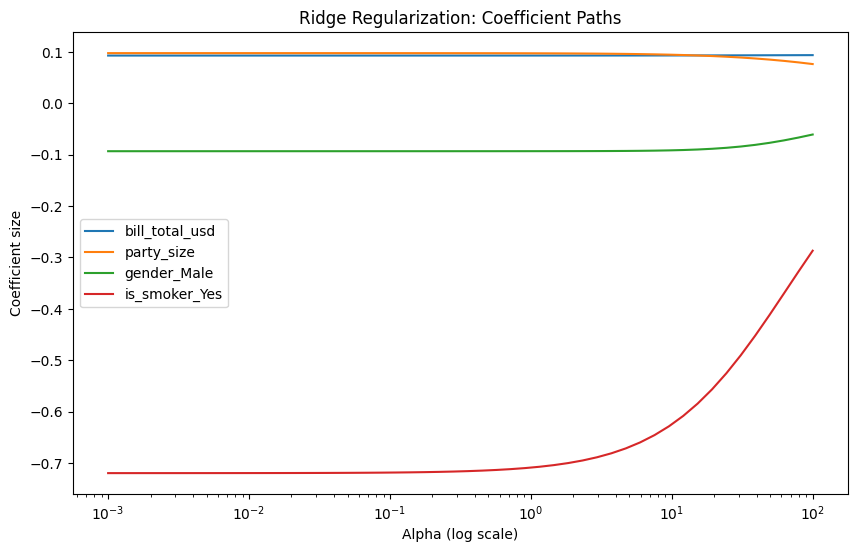

In [7]:
import matplotlib.pyplot as plt
import numpy as np

alphas = np.logspace(-3, 2, 50)
coefs_ridge = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train, y_train)
    coefs_ridge.append(r.coef_)

coefs_ridge = np.array(coefs_ridge)

fig, ax = plt.subplots(figsize=(10,6))

for i, f in enumerate(features):
    ax.plot(alphas, coefs_ridge[:, i], label=f)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Coefficient size")
ax.set_title("Ridge Regularization: Coefficient Paths")
ax.legend()
plt.show()


In [8]:
from src.helpers import save_and_log_plot

save_and_log_plot(
    ax,
    "reports/figures/ridge_coefficient_paths.png",
    df=df_work,
    chart_type="line",
    library="matplotlib",
    x="alpha",
    y="coefficient",
    notebook="notebooks/07_Regularization_and_Overfitting.ipynb",
    notes="Coefficient shrinkage under Ridge.",
    timestamped=True,
)


✅ Saved Seaborn Axes figure to: reports/figures/ridge_coefficient_paths_2025-11-23_0737.png
📝 Logged metadata → reports/figures/ridge_coefficient_paths_2025-11-23_0737.json


(PosixPath('reports/figures/ridge_coefficient_paths_2025-11-23_0737.png'),
 PosixPath('reports/figures/ridge_coefficient_paths_2025-11-23_0737.json'))

## OVERFITTING

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

# Reproducibility
np.random.seed(42)

# 1) Basic settings
n_samples = 80          # small → easier to overfit
n_noise_features = 50   # many junk features

# 2) True signal feature
x_signal = np.random.uniform(-3, 3, size=n_samples)

# 3) Generate pure noise features
noise_features = {
    f"noise_{i+1}": np.random.normal(0, 1, size=n_samples)
    for i in range(n_noise_features)
}

# 4) True relationship for y (regression target)
#    y = 2.5 * x_signal - 1.0 + random noise
beta_signal = 2.5
intercept = -1.0
eps = np.random.normal(0, 1.5, size=n_samples)  # noise on target

y = intercept + beta_signal * x_signal + eps

# 5) Build DataFrame
df_overfit = pd.DataFrame(noise_features)
df_overfit["x_signal"] = x_signal
df_overfit["y"] = y

# 6) Save to data/processed/
output_path = Path("data/processed/overfit_synthetic.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_overfit.to_csv(output_path, index=False)

print(f"✅ Saved overfitting dataset to: {output_path}")
df_overfit.head()


✅ Saved overfitting dataset to: data/processed/overfit_synthetic.csv


,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,...,noise_43,noise_44,noise_45,noise_46,noise_47,noise_48,noise_49,noise_50,x_signal,y
0,0.331263,0.813517,-0.485364,0.812862,2.189803,-0.553649,1.006293,0.481009,0.924027,-0.074433,...,-1.292625,-0.183150,-0.815376,0.160490,-0.370583,-0.397680,0.429341,0.568103,-0.752759,-1.438917
1,0.975545,-1.230864,0.081874,0.629629,-0.808298,-1.197878,-0.576892,0.223884,-0.184902,0.620672,...,-0.532169,-0.356673,-1.066235,2.212531,-1.348047,-1.184031,0.379640,-1.049655,2.704286,5.405197
2,-0.479174,0.227460,2.314659,-0.828995,-0.839722,1.964725,0.835692,-0.790474,-0.522723,0.177701,...,-0.607354,1.180641,2.124771,-0.360039,-0.714681,-0.399899,-0.556119,1.362563,1.391964,3.604759
3,-0.185659,1.307143,-1.867265,-0.560181,-0.599393,0.035264,-1.129707,0.471468,1.049009,-1.335344,...,-0.077221,-0.627313,1.331339,-0.728077,0.521280,0.269295,-0.130060,1.640615,0.591951,0.898779
4,-1.106335,-1.607483,0.686260,0.747294,-2.123896,-0.699726,0.529804,1.882024,-0.704344,0.380198,...,0.425844,0.045223,1.920368,0.373349,0.321679,-0.044893,1.669070,3.152057,-2.063888,-7.586086


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load synthetic overfit data
# ---------------------------
df = pd.read_csv("data/processed/overfit_synthetic.csv")

# Features = all columns except y
X = df.drop(columns=["y"])
y = df["y"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------
# 2. Fit models
# ---------------------------
models = {
    "OLS (Linear Regression)": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.1)": Lasso(alpha=0.1),
    "ElasticNet (α=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5),
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # Manual RMSE (because your sklearn lacks squared=False)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test  = mean_squared_error(y_test, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)

    results.append({
        "Model": name,
        "Train_R2": r2_score(y_train, y_pred_train),
        "Test_R2": r2_score(y_test, y_pred_test),
        "Train_RMSE": rmse_train,
        "Test_RMSE": rmse_test,
    })

results_df = pd.DataFrame(results)
results_df



,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE
0,OLS (Linear Regression),0.997409,0.250437,0.257245,4.147896
1,Ridge (α=1.0),0.995798,0.520403,0.327599,3.317888
2,Lasso (α=0.1),0.965342,0.917205,0.940859,1.378557
3,"ElasticNet (α=0.1, l1_ratio=0.5)",0.976763,0.890275,0.770392,1.587001


## 🔩 Coefficient Shrinkage: OLS vs Ridge vs Lasso vs ElasticNet

Regularization reduces model instability by shrinking coefficients toward zero.

- **OLS (linear regression)**: no penalty → coefficients can blow up under multicollinearity  
- **Ridge (L2)**: shrinks coefficients but never fully zeroes them  
- **Lasso (L1)**: can shrink some coefficients *exactly to zero* → feature selection  
- **ElasticNet (L1 + L2 mix)**: compromise between Ridge and Lasso

We'll compare all 4 models using the same synthetic dataset and visualize how the coefficients change.


In [14]:
import pandas as pd

df = pd.read_csv("data/processed/tips_synthetic.csv").copy()

# Identify non-numeric columns
non_num = df.select_dtypes(include=['object', 'category']).columns
print("Non-numeric columns:", list(non_num))

# Encode ALL string columns using one-hot encoding
df_encoded = pd.get_dummies(df, columns=non_num, drop_first=True)

df_encoded.head()


Non-numeric columns: ['gender', 'is_smoker']


,bill_total_usd,party_size,tip_usd,tip_pct,gender_Male,is_smoker_Yes
0,43.71,1,3.65,0.084,False,True
1,95.56,4,9.88,0.103,True,False
2,75.88,2,7.78,0.103,False,False
3,63.88,4,12.78,0.200,True,False
4,24.04,2,4.36,0.181,False,False


In [15]:
X = df_encoded.drop(columns=["tip_usd"])
y = df_encoded["tip_usd"]


<Figure size 1200x600 with 0 Axes>

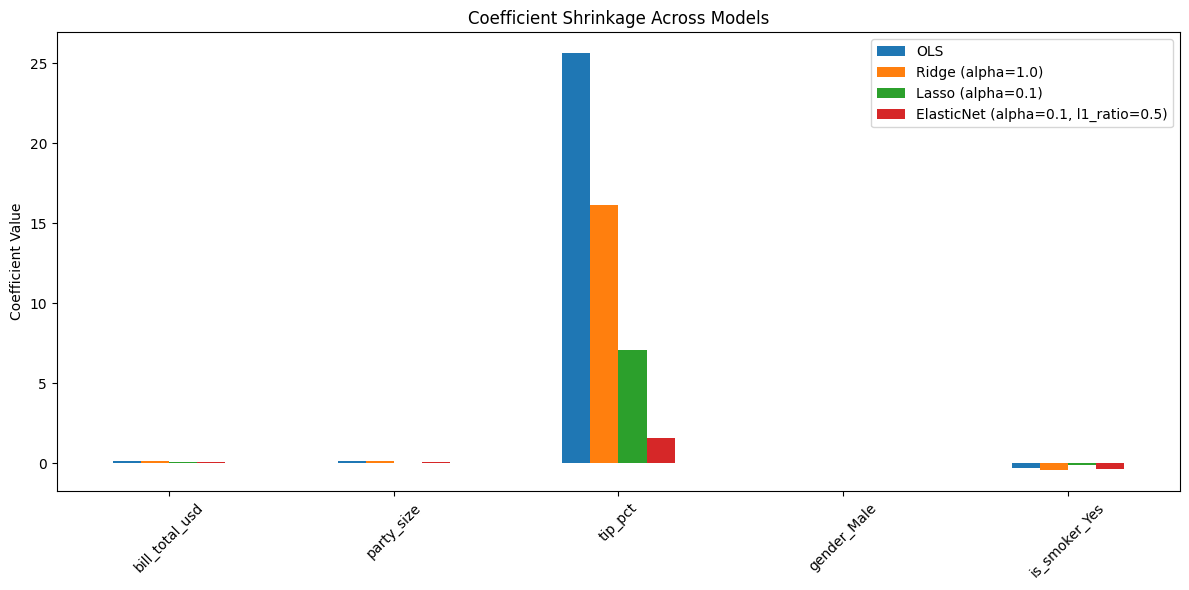

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load synthetic dataset
df = pd.read_csv("data/processed/tips_synthetic.csv").copy()

# Encode all non-numeric columns
non_num = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=non_num, drop_first=True)

# Build X and y
X = df_encoded.drop(columns=["tip_usd"])
y = df_encoded["tip_usd"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "OLS": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "ElasticNet (alpha=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

coef_df = pd.DataFrame(index=X.columns)

# Fit and collect coefficients
for name, model in models.items():
    model.fit(X_train, y_train)
    coef_df[name] = model.coef_

# Plot
plt.figure(figsize=(12,6))
ax = coef_df.plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Shrinkage Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
from src.helpers import save_and_log_plot

save_and_log_plot(
    ax,
    "reports/figures/coefficient_shrinkage_across_models.png",
    df=coef_df,
    chart_type="barplot",
    library="matplotlib",
    x="Feature",
    y="Coefficient Value",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    notes="Comparing coefficient shrinkage across OLS, Ridge, Lasso, and ElasticNet.",
    timestamped=True,
)

✅ Saved Seaborn Axes figure to: reports/figures/coefficient_shrinkage_across_models_2025-11-23_0902.png
📝 Logged metadata → reports/figures/coefficient_shrinkage_across_models_2025-11-23_0902.json


(PosixPath('reports/figures/coefficient_shrinkage_across_models_2025-11-23_0902.png'),
 PosixPath('reports/figures/coefficient_shrinkage_across_models_2025-11-23_0902.json'))

## 🧠 Coefficient Shrinkage Across Models — Notebook Summary

This chart compares how OLS, Ridge, Lasso, and ElasticNet treat feature coefficients when predicting the target.
Each model applies a different level of “pressure” to the coefficients:

* **OLS**: No penalty → coefficients can become very large, especially with noisy or correlated data.
* **Ridge**: L2 penalty → shrinks coefficients smoothly toward zero but never eliminates them.
* **Lasso**: L1 penalty → aggressively pushes small or noisy coefficients **all the way to zero**.
* **ElasticNet**: Mix of L1 + L2 → both shrinks and can zero-out features.

---

## ✏️ Interpretation Summary

* **tip_pct** has a very large coefficient under **OLS**, showing that OLS is over-relying on a single feature in the noisy synthetic dataset.
* **Ridge** pulls this coefficient down significantly, reducing reliance on a single noisy input.
* **Lasso** shrinks it even further and zeros-out weaker predictors.
* **ElasticNet** sits in between — shrinking aggressively, but not as extremely as Lasso.

---

Regularization helps a model:
* become more **stable**
* avoid **overfitting**
* handle **multicollinearity**
* reduce model **variance**
* identify **important features** (Lasso removes weak ones)

---

## 🍼 ELI5 Version

Imagine each feature is a kid yelling hints about what the tip will be:
* **OLS** lets all kids shout at full volume — even if they’re wrong.
* **Ridge** says, “Everybody talk quieter.”
* **Lasso** says, “If you don’t have anything truly useful to say, be quiet.”
* **ElasticNet** says, “Use inside voices, and some of you should stop talking altogether.”

Regularization keeps the model from believing noisy kids too much.

---

## 📎 Key Takeaways for Your Notes
* Large coefficients in OLS often signal **overfitting**.
* Ridge reduces extreme coefficients but keeps all features.
* Lasso reduces extreme coefficients **and** removes irrelevant features.
* ElasticNet is a compromise and works well when:
   * There are many correlated features
   * You want both shrinkage + feature selection

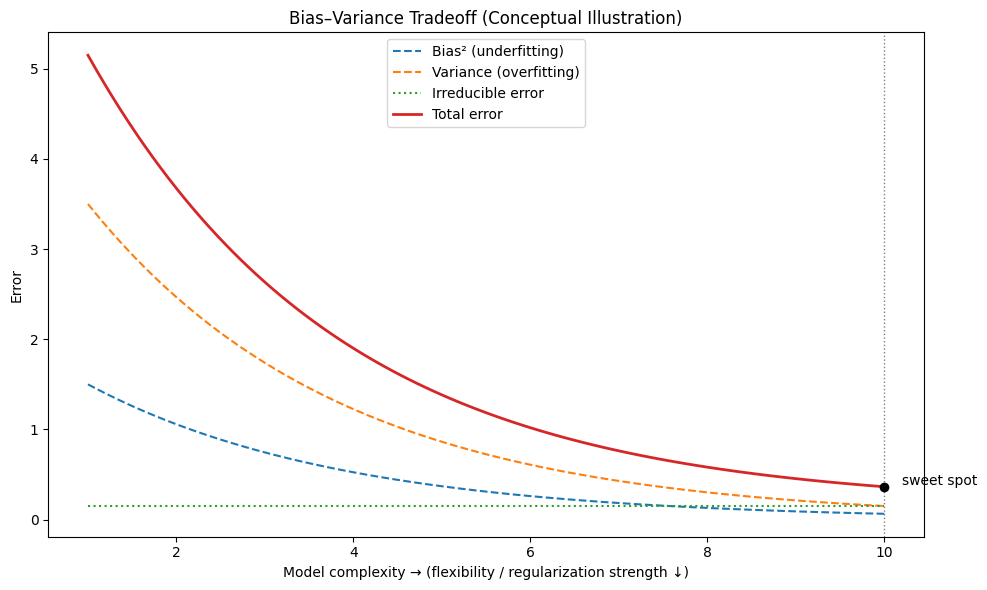

✅ Saved Matplotlib figure to: reports/figures/bias_variance_tradeoff_2025-11-23_1013.png
📝 Logged metadata → reports/figures/bias_variance_tradeoff_2025-11-23_1013.json


<Figure size 640x480 with 0 Axes>

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fake "model complexity" axis (e.g. polynomial degree, number of features, etc.)
complexity = np.linspace(1, 10, 100)

# 2. Create smooth, cartoon-style curves (not real data – just pedagogical)
bias2      = 1.5 * np.exp(-0.35 * (complexity - 1))      # high at low complexity, drops with complexity
variance   = 0.15 * np.exp(0.35 * (complexity - 10))**-1 # low at low complexity, rises with complexity
noise      = np.full_like(complexity, 0.15)              # irreducible error (flat)
total_err  = bias2 + variance + noise

# 3. Find approximate "sweet spot" where total error is smallest
best_idx   = np.argmin(total_err)
best_x     = complexity[best_idx]
best_y     = total_err[best_idx]

# 4. Plot
plt.figure(figsize=(10, 6))

ax = plt.plot(complexity, bias2,     label="Bias² (underfitting)",  linestyle="--")
plt.plot(complexity, variance,  label="Variance (overfitting)", linestyle="--")
plt.plot(complexity, noise,     label="Irreducible error",      linestyle=":")
plt.plot(complexity, total_err, label="Total error",            linewidth=2)

# Mark the sweet spot
plt.axvline(best_x, color="gray", linestyle=":", linewidth=1)
plt.scatter([best_x], [best_y], color="black", zorder=5)
plt.text(best_x + 0.2, best_y + 0.02, "sweet spot", fontsize=10)

plt.xlabel("Model complexity → (flexibility / regularization strength ↓)")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff (Conceptual Illustration)")
plt.legend()
plt.tight_layout()

# Optional: save figure to disk
plt.savefig("reports/figures/bias_variance_tradeoff.png", dpi=300, bbox_inches="tight")

plt.show()

# (Optional logging helper, if you have src.helpers.save_and_log_plot available)
try:

    from src.helpers import save_and_log_plot
    import matplotlib.pyplot as plt
    
    fig = plt.gcf()  # current figure
    
    save_and_log_plot(
        fig,
        "reports/figures/bias_variance_tradeoff.png",
        df=None,                                # no underlying dataset; that's fine
        chart_type="line",
        library="matplotlib",
        x="model_complexity",
        y="error_components",
        dataset_name="synthetic_bias_variance_demo",
        dataset_path=None,
        notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
        notes="Conceptual bias–variance tradeoff for regularization.",
        timestamped=True,
    )
    
    # from src.helpers import save_and_log_plot
    
    # save_and_log_plot(
    #     ax,
    #     "reports/figures/bias_variance_tradeoff.png",
    #     df="synthetic_bias_variance_demo",
    #     chart_type="line",
    #     library="matplotlib",
    #     x="model_complexity",
    #     y="error_components",
    #     dataset_name="synthetic_bias_variance_demo",
    #     dataset_path="data/processed/dataset_doesnotexist.csv",
    #     notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    #     notes="Conceptual bias–variance tradeoff for regularization.",
    #     timestamped=True,
    # )    
    
    # from src.helpers import save_and_log_plot
    # # fig = plt.gcf()

    # save_and_log_plot(
    #     ax,
    #     "reports/figures/bias_variance_tradeoff.png",
    #     df=coef_df,
    #     chart_type="barplot",
    #     library="matplotlib",
    #     x="Feature",
    #     y="Coefficient Value",
    #     dataset_name="synthetic_bias_variance_demo",
    #     dataset_path=None,
    #     notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    #     notes="Conceptual bias–variance tradeoff for regularization.",
    #     timestamped=True,
    # )    
    
    # save_and_log_plot(
    #     fig,
    #     "bias_variance_tradeoff",
    #     folder="session7",
    #     chart_type="line",
    #     library="matplotlib",
    #     x="model_complexity",
    #     y="error_components",
    #     dataset_name="synthetic_bias_variance_demo",
    #     dataset_path=None,
    #     notebook="notebooks/07_Regularization_Overfitting_Model_Stability.ipynb",
    #     notes="Conceptual bias–variance tradeoff for regularization.",
    #     timestamped=True,
    # )
    
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")
